In [3]:
from sklearn.datasets import make_moons, make_circles
import numpy as np
from matplotlib import pyplot as plt

## Make moons dataset

In [1]:
from src.golem.Pipeline import Pipeline
from sklearn.metrics import accuracy_score

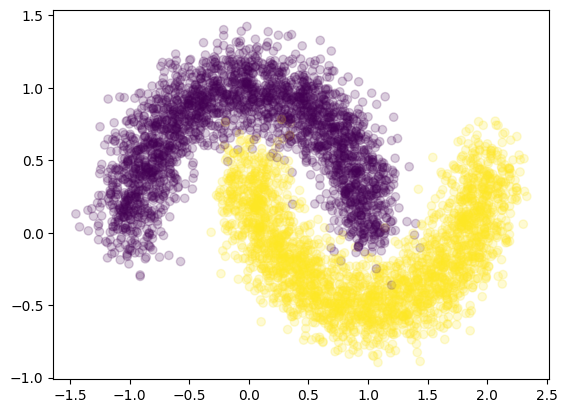

In [4]:
X,y = make_moons(n_samples=5000, noise=0.15, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.2)

In [5]:
from src.golem.Pipeline import Pipeline
from sklearn.metrics import accuracy_score
pipeline = Pipeline(X, y, multiclass=False)
pipeline.get_data(train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, batch_size=256)

In [6]:
mlp_model, mlp_acc = pipeline.fit_mlp(epochs=40, depth=12, hidden_dim=64, learning_rate=1e-3)
print(f"MLP Test Accuracy: {mlp_acc*100:.2f}%")

Epoch 1/40
Accuracy: 0.495
Epoch 2/40
Accuracy: 0.495
Epoch 3/40
Accuracy: 0.868
Epoch 4/40
Accuracy: 0.873
Epoch 5/40
Accuracy: 0.895
Epoch 6/40
Accuracy: 0.949
Epoch 7/40
Accuracy: 0.965
Epoch 8/40
Accuracy: 0.985
Epoch 9/40
Accuracy: 0.987
Epoch 10/40
Accuracy: 0.99
Epoch 11/40
Accuracy: 0.992
Epoch 12/40
Accuracy: 0.982
Epoch 13/40
Accuracy: 0.976
Epoch 14/40
Accuracy: 0.989
Epoch 15/40
Accuracy: 0.987
Epoch 16/40
Accuracy: 0.988
Epoch 17/40
Accuracy: 0.993
Epoch 18/40
Accuracy: 0.992
Epoch 19/40
Accuracy: 0.992
Epoch 20/40
Accuracy: 0.991
Epoch 21/40
Accuracy: 0.991
Epoch 22/40
Accuracy: 0.992
Epoch 23/40
Accuracy: 0.993
Epoch 24/40
Accuracy: 0.991
Epoch 25/40
Accuracy: 0.989
Epoch 26/40
Accuracy: 0.991
Epoch 27/40
Accuracy: 0.991
Epoch 28/40
Accuracy: 0.994
Epoch 29/40
Accuracy: 0.992
Epoch 30/40
Accuracy: 0.991
Epoch 31/40
Accuracy: 0.993
Epoch 32/40
Accuracy: 0.991
Epoch 33/40
Accuracy: 0.991
Epoch 34/40
Accuracy: 0.985
Epoch 35/40
Accuracy: 0.988
Epoch 36/40
Accuracy: 0.987
Ep

In [7]:
pipeline.extract_embeddings()
print(f"Embedding shape: {pipeline.embedings[0].shape}")

Embedding shape: (3000, 32)


In [11]:
rf_simple, rf_simple_score = pipeline.train_random_forest(use_embeddings=False)
rf_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], rf_simple.predict(pipeline.X_sa_part[2]))
print(f"RFAccuracy: {rf_simple_test_acc}")

c:\Users\wojtek\VSCODE\golem-t13\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
c:\Users\wojtek\VSCODE\golem-t13\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-01-15 01:16:51,449] A new study created in memory with name: no-name-75d73934-f769-49f1-8468-b58a230cc03b


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-01-15 01:16:51,708] Trial 0 finished with value: 0.9886666666666666 and parameters: {'n_estimators': 137, 'max_depth': 25, 'min_samples_split': 35, 'min_samples_leaf': 16, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9886666666666666.
[I 2026-01-15 01:16:52,229] Trial 1 finished with value: 0.9876666666666666 and parameters: {'n_estimators': 283, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9886666666666666.
[I 2026-01-15 01:16:52,611] Trial 2 finished with value: 0.987 and parameters: {'n_estimators': 223, 'max_depth': 32, 'min_samples_split': 25, 'min_samples_leaf': 34, 'max_features': 'log2'}. Best is trial 0 with value: 0.9886666666666666.
[I 2026-01-15 01:16:52,653] Trial 3 finished with value: 0.9876666666666666 and parameters: {'n_estimators': 20, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 34, 'max_features': 'log2'}. Best is trial 0 with value: 0.9886666666666666.
[I 20

KeyboardInterrupt: 

In [ ]:
rf_hybrid, rf_hybrid_score = pipeline.train_random_forest(use_embeddings=True)
rf_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], rf_hybrid.predict(pipeline.embedings[2]))
print(f"embedings+RF Accuracy: {rf_hybrid_test_acc}")

[I 2026-01-15 01:03:14,115] A new study created in memory with name: no-name-562790d4-212d-4e03-b1ed-5579f089b2b8


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-15 01:03:19,946] Trial 0 finished with value: 0.4923333333333334 and parameters: {'n_estimators': 335, 'max_depth': 15, 'min_samples_split': 24, 'min_samples_leaf': 21, 'max_features': None}. Best is trial 0 with value: 0.4923333333333334.
[I 2026-01-15 01:03:20,309] Trial 1 finished with value: 0.6181666666666668 and parameters: {'n_estimators': 233, 'max_depth': 2, 'min_samples_split': 27, 'min_samples_leaf': 37, 'max_features': 'log2'}. Best is trial 1 with value: 0.6181666666666668.
[I 2026-01-15 01:03:20,465] Trial 2 finished with value: 0.6298333333333332 and parameters: {'n_estimators': 107, 'max_depth': 2, 'min_samples_split': 38, 'min_samples_leaf': 37, 'max_features': 'log2'}. Best is trial 2 with value: 0.6298333333333332.
[I 2026-01-15 01:03:22,560] Trial 3 finished with value: 0.5578333333333333 and parameters: {'n_estimators': 650, 'max_depth': 14, 'min_samples_split': 33, 'min_samples_leaf': 38, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.6298333333

In [ ]:
dt_simple, dt_simple_score = pipeline.train_decision_tree(use_embeddings=False)
dt_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], dt_simple.predict(pipeline.X_sa_part[2]))
print(f"Decision Tree (Simple) Test Accuracy: {dt_simple_test_acc*100:.2f}%")

c:\Users\wojtek\VSCODE\golem-t13\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
c:\Users\wojtek\VSCODE\golem-t13\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-01-15 01:11:33,006] A new study created in memory with name: no-name-54c8bab8-8a66-4525-8141-39d6fac6cfbe


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-15 01:11:33,016] Trial 0 finished with value: 0.9586666666666668 and parameters: {'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 46, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9586666666666668.
[I 2026-01-15 01:11:33,021] Trial 1 finished with value: 0.911 and parameters: {'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 27, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9586666666666668.
[I 2026-01-15 01:11:33,028] Trial 2 finished with value: 0.8723333333333334 and parameters: {'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 46, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9586666666666668.
[I 2026-01-15 01:11:33,033] Trial 3 finished with value: 0.877 and parameters: {'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 28, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9586666666666668.
[I 2026-01-15 01:11:33,037] Trial 4 finished with value: 0.9776666666666666 and parameters: {'max_depth': 

In [ ]:
dt_hybrid, dt_hybrid_score = pipeline.train_decision_tree(use_embeddings=True)
dt_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], dt_hybrid.predict(pipeline.embedings[2]))
print(f"Decision Tree (Hybrid) Test Accuracy: {dt_hybrid_test_acc*100:.2f}%")

c:\Users\wojtek\VSCODE\golem-t13\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
c:\Users\wojtek\VSCODE\golem-t13\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-01-15 01:11:52,352] A new study created in memory with name: no-name-0dc7f833-cace-4a86-88cb-073209e9210c


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-15 01:11:52,364] Trial 0 finished with value: 0.6705000000000001 and parameters: {'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 21, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6705000000000001.
[I 2026-01-15 01:11:52,369] Trial 1 finished with value: 0.6633333333333333 and parameters: {'max_depth': 2, 'min_samples_split': 3, 'min_samples_leaf': 32, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6705000000000001.
[I 2026-01-15 01:11:52,375] Trial 2 finished with value: 0.34299999999999997 and parameters: {'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 42, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6705000000000001.
[I 2026-01-15 01:11:52,383] Trial 3 finished with value: 0.651 and parameters: {'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 42, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6705000000000001.
[I 2026-01-15 01:11:52,390] Trial 4 finished with value: 0.6533333333333333 and parameters: 

## Results Comparison

In [ ]:
print(f"MLP Only: {mlp_acc*100:.2f}%")
print(f"Random Forest (Simple): {rf_simple_test_acc*100:.2f}%")
print(f"Random Forest (Hybrid - MLP + RF): {rf_hybrid_test_acc*100:.2f}%")
print(f"Decision Tree (Simple): {dt_simple_test_acc*100:.2f}%")
print(f"Decision Tree (Hybrid - MLP + DT): {dt_hybrid_test_acc*100:.2f}%")

## Make circles dataset

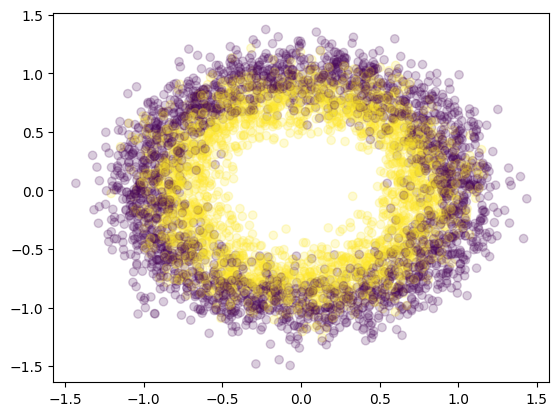

In [8]:
X,y = make_circles(n_samples=5000, noise=0.15, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.2)